# Parallel N-Body Gravitational Simulator
## Benchmark Analysis & Visualization

This notebook loads benchmark CSV results exported from the C++ simulator,
merges them into a combined dataset, prints summary tables, and generates
performance graphs across all parallel modes.



### Benchmark Commands

Run these from `NBodySimulator/x64/Debug/` before opening this notebook:

```bash
# Serial + OpenMP + Barnes-Hut + GPU  (no mpiexec)
NBodySimulator.exe bench gpu
# → benchmark_gpu_n1.csv

# MPI with 2 processes
mpiexec -n 2 NBodySimulator.exe bench mpi
# → benchmark_mpi_n2.csv

# MPI with 4 processes
mpiexec -n 4 NBodySimulator.exe bench mpi
# → benchmark_mpi_n4.csv

# MPI with 6 processes
mpiexec -n 6 NBodySimulator.exe bench mpi
# → benchmark_mpi_n6.csv
```

> All CSV files are saved automatically in `NBodySimulator/x64/Debug/`


## 1. Imports & Setup

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os
import sys

# Output folder for saved graphs
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Libraries loaded successfully.")
print(f"Graphs will be saved to: {os.path.abspath(RESULTS_DIR)}/")


Libraries loaded successfully.
Graphs will be saved to: d:\Dev\PDC\NBodySimulator\results/


## 2. Load CSV Files

In [ ]:
CSV_DIR = r"..\x64\Debug"   # relative to this notebook's location
                            # adjust if running notebook from a different folder
expected_files = {
    "benchmark_gpu_n1.csv": "gpu",
    "benchmark_mpi_n2.csv": "mpi",
    "benchmark_mpi_n4.csv": "mpi",
    "benchmark_mpi_n6.csv": "mpi",
}

dfs = []
for fname, ftype in expected_files.items():
    fpath = os.path.join(CSV_DIR, fname)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        if 'mpi_procs' not in df.columns:
            df['mpi_procs'] = 1
        df['source'] = ftype
        dfs.append(df)
        print(f"Loaded  {fname}  ({len(df)} rows)")
    else:
        print(f"Missing {fname}  — run benchmark first")

if not dfs:
    print("\nNo CSV files found. Run the benchmark commands above first.")
    sys.exit(1)

# Merge all into one dataframe
raw_df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows loaded: {len(raw_df)}")


Loaded  benchmark_gpu_n1.csv  (24 rows)
Loaded  benchmark_mpi_n2.csv  (24 rows)
Loaded  benchmark_mpi_n4.csv  (24 rows)
Loaded  benchmark_mpi_n6.csv  (24 rows)

Total rows loaded: 96


## 3. Separate & Inspect Datasets

In [20]:
# GPU benchmark — Serial, OpenMP, Barnes-Hut, GPU (single process, full OpenMP threads)
gpu_df  = raw_df[raw_df['source'] == 'gpu'].copy()

# MPI benchmarks by process count
mpi2_df = raw_df[(raw_df['source'] == 'mpi') & (raw_df['mpi_procs'] == 2)].copy()
mpi4_df = raw_df[(raw_df['source'] == 'mpi') & (raw_df['mpi_procs'] == 4)].copy()
mpi6_df = raw_df[(raw_df['source'] == 'mpi') & (raw_df['mpi_procs'] == 6)].copy()

sizes = sorted(raw_df['particle_count'].unique())
print("Particle counts found:", sizes)

mpi_datasets = []
if not mpi2_df.empty: mpi_datasets.append((mpi2_df, 'MPI-2', 2))
if not mpi4_df.empty: mpi_datasets.append((mpi4_df, 'MPI-4', 4))
if not mpi6_df.empty: mpi_datasets.append((mpi6_df, 'MPI-6', 6))

print(f"MPI datasets available: {[f'n={p}' for _,_,p in mpi_datasets]}")


Particle counts found: [np.int64(100), np.int64(500), np.int64(1000), np.int64(2500), np.int64(5000), np.int64(10000)]
MPI datasets available: []


## 4. Summary Tables

In [21]:
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("=" * 70)
print("GPU BENCHMARK (Serial / OpenMP / Barnes-Hut / GPU)")
print("=" * 70)
display(gpu_df[['particle_count','mode','avg_ms','fps','speedup']]
        .sort_values(['particle_count','mode'])
        .reset_index(drop=True))

for dset, label, nproc in mpi_datasets:
    print(f"\n{'=' * 70}")
    print(f"MPI BENCHMARK — {nproc} PROCESSES")
    print("=" * 70)
    display(dset[['particle_count','mode','avg_ms','fps','speedup']]
            .sort_values(['particle_count','mode'])
            .reset_index(drop=True))


GPU BENCHMARK (Serial / OpenMP / Barnes-Hut / GPU)


,particle_count,mode,avg_ms,fps,speedup
0,100,Barnes-Hut,2.938,340.316,0.836
1,100,GPU,2.226,449.159,1.103
2,100,OpenMP,2.265,441.576,1.085
3,100,Serial,2.457,407.030,1.000
4,500,Barnes-Hut,49.185,20.331,1.124
5,500,GPU,44.036,22.709,1.256
6,500,OpenMP,53.777,18.596,1.028
7,500,Serial,55.301,18.083,1.000
8,1000,Barnes-Hut,195.468,5.116,1.080
9,1000,GPU,194.600,5.139,1.085


## 5. Export Combined CSV

In [22]:
combined_path = os.path.join(RESULTS_DIR, "benchmark_combined.csv")
raw_df.to_csv(combined_path, index=False)
print(f"Saved combined CSV → {combined_path}")
display(raw_df.head(10))


Saved combined CSV → results\benchmark_combined.csv


,particle_count,mode,avg_ms,fps,speedup,mpi_procs,source
0,100,Serial,2.457,407.030,1.000,1,gpu
1,100,OpenMP,2.265,441.576,1.085,1,gpu
2,100,Barnes-Hut,2.938,340.316,0.836,1,gpu
3,100,GPU,2.226,449.159,1.103,1,gpu
4,500,Serial,55.301,18.083,1.000,1,gpu
5,500,OpenMP,53.777,18.596,1.028,1,gpu
6,500,Barnes-Hut,49.185,20.331,1.124,1,gpu
7,500,GPU,44.036,22.709,1.256,1,gpu
8,1000,Serial,211.149,4.736,1.000,1,gpu
9,1000,OpenMP,208.475,4.797,1.013,1,gpu


## 6. Plot Style Configuration

In [23]:
BG       = '#0d0d1a'
PANEL_BG = '#111130'
GRID_C   = '#1e1e3a'

COLORS = {
    'Serial':     '#e74c3c',
    'OpenMP':     '#3498db',
    'Barnes-Hut': '#2ecc71',
    'GPU':        '#9b59b6',
    'MPI-1':      '#fd79a8',
    'MPI-2':      '#f39c12',
    'MPI-4':      '#e17055',
    'MPI-6':      '#fdcb6e',
}

MARKERS = {
    'Serial':     'o',
    'OpenMP':     's',
    'Barnes-Hut': '^',
    'GPU':        'D',
    'MPI-1':      'P',
    'MPI-2':      'X',
    'MPI-4':      'P',
    'MPI-6':      '*',
}

def get_color(label):
    for k, v in COLORS.items():
        if k.lower() in label.lower():
            return v
    return '#aaaaaa'

def get_marker(label):
    for k, v in MARKERS.items():
        if k.lower() in label.lower():
            return v
    return 'o'

def style(ax, title, xlabel, ylabel, legend=True, log_y=False):
    ax.set_facecolor(PANEL_BG)
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, color='#aaaaaa', fontsize=9)
    ax.set_ylabel(ylabel, color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    for sp in ['top', 'right']:  ax.spines[sp].set_visible(False)
    for sp in ['bottom', 'left']: ax.spines[sp].set_color('#333355')
    ax.grid(True, color=GRID_C, linewidth=0.6, linestyle='--', alpha=0.9)
    if log_y:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    if legend:
        ax.legend(facecolor='#0d0d1a', edgecolor='#333355',
                  labelcolor='white', fontsize=8, framealpha=0.9)

print("Style configuration loaded.")


Style configuration loaded.


## 7. Graph 1 — Update Time vs Particle Count

Saved → results\graph1_update_time.png


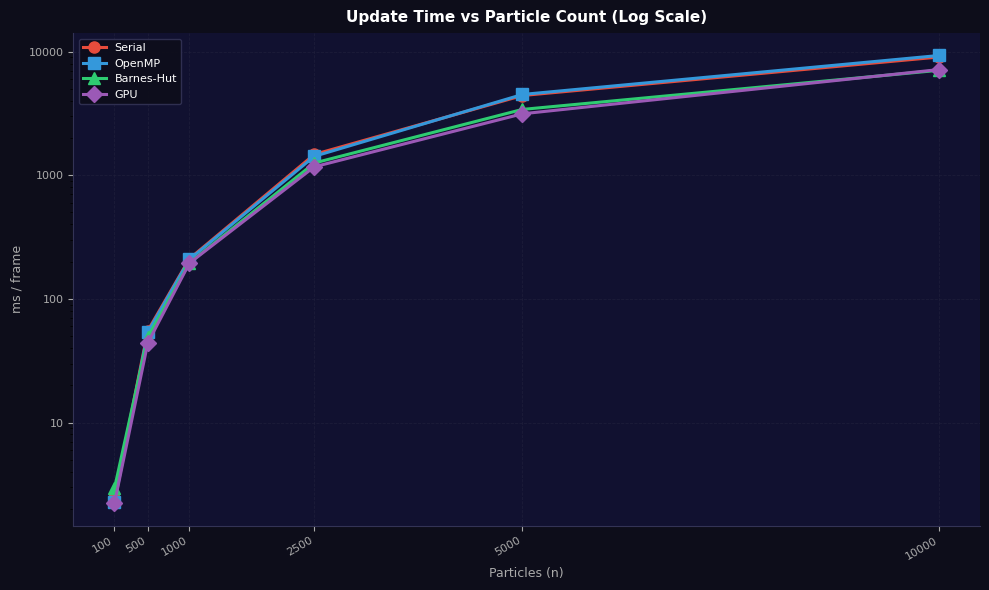

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)

for mode in ['Serial', 'OpenMP', 'Barnes-Hut', 'GPU']:
    sub = gpu_df[gpu_df['mode'] == mode].sort_values('particle_count')
    if sub.empty: continue
    ax.plot(sub['particle_count'], sub['avg_ms'],
            marker=get_marker(mode), color=get_color(mode),
            linewidth=2.2, markersize=8, label=mode)

style(ax, 'Update Time vs Particle Count (Log Scale)',
      'Particles (n)', 'ms / frame', log_y=True)
ax.set_xticks(sizes)
ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph1_update_time.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 8. Graph 2 — Speedup over Serial

Saved → results\graph2_speedup.png


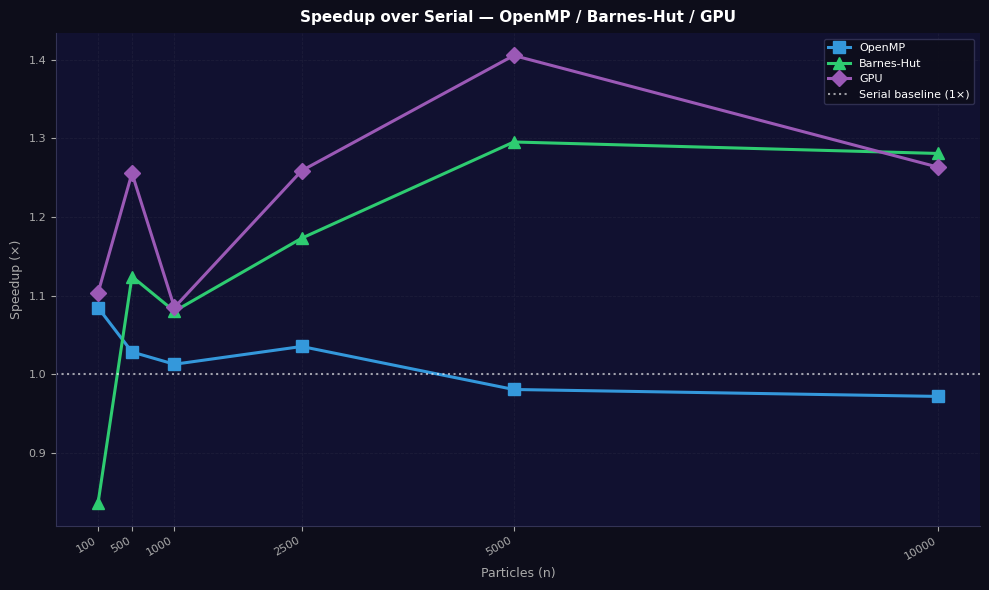

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)

for mode in ['OpenMP', 'Barnes-Hut', 'GPU']:
    sub = gpu_df[gpu_df['mode'] == mode].sort_values('particle_count')
    if sub.empty: continue
    ax.plot(sub['particle_count'], sub['speedup'],
            marker=get_marker(mode), color=get_color(mode),
            linewidth=2.2, markersize=8, label=mode)

ax.axhline(1.0, color='white', linestyle=':', linewidth=1.5,
           alpha=0.6, label='Serial baseline (1×)')

style(ax, 'Speedup over Serial — OpenMP / Barnes-Hut / GPU',
      'Particles (n)', 'Speedup (×)')
ax.set_xticks(sizes)
ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph2_speedup.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 9. Graph 3 — FPS vs Particle Count

Saved → results\graph3_fps.png


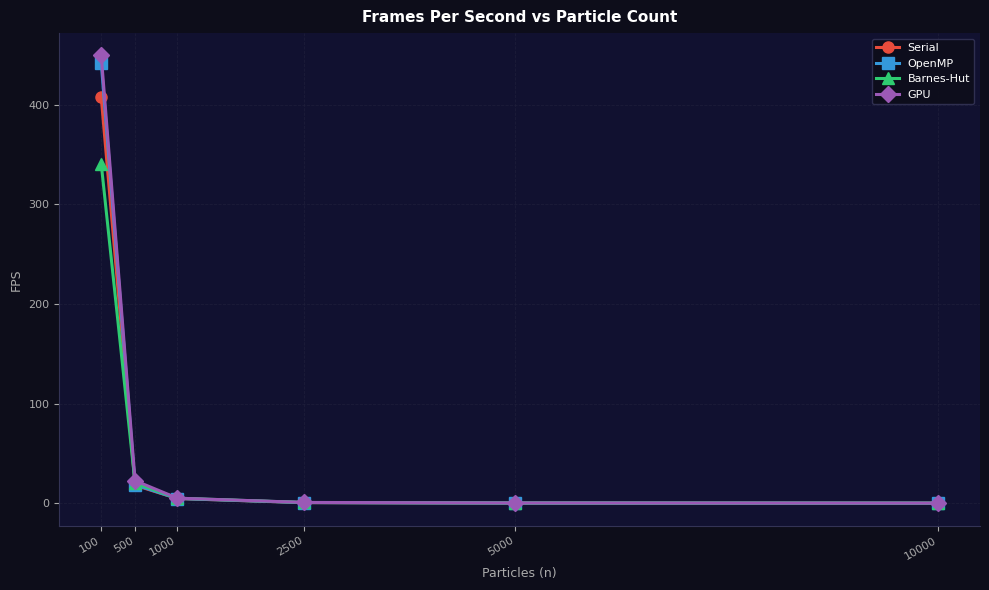

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)

for mode in ['Serial', 'OpenMP', 'Barnes-Hut', 'GPU']:
    sub = gpu_df[gpu_df['mode'] == mode].sort_values('particle_count')
    if sub.empty: continue
    ax.plot(sub['particle_count'], sub['fps'],
            marker=get_marker(mode), color=get_color(mode),
            linewidth=2.2, markersize=8, label=mode)

style(ax, 'Frames Per Second vs Particle Count',
      'Particles (n)', 'FPS')
ax.set_xticks(sizes)
ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph3_fps.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 10. Graph 4 — MPI Scaling: Update Time

Saved → results\graph4_mpi_scaling_time.png


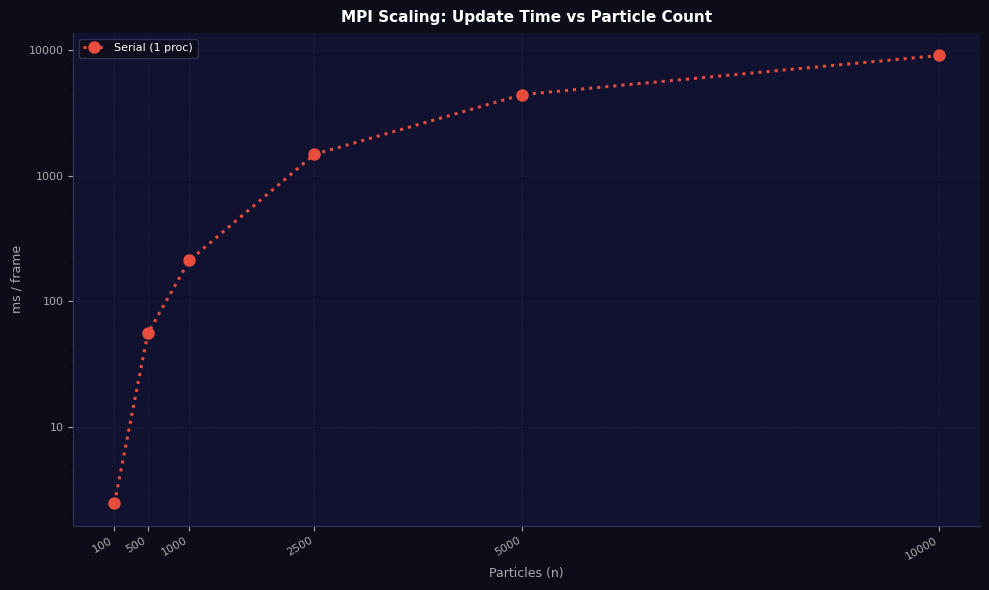

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)

serial_sub = gpu_df[gpu_df['mode'] == 'Serial'].sort_values('particle_count')
ax.plot(serial_sub['particle_count'], serial_sub['avg_ms'],
        marker='o', color=get_color('Serial'), linewidth=2.2,
        markersize=8, label='Serial (1 proc)', linestyle=':')

for dset, label, nproc in mpi_datasets:
    sub = dset[dset['mode'] == 'MPI'].sort_values('particle_count')
    if sub.empty: continue
    ax.plot(sub['particle_count'], sub['avg_ms'],
            marker=get_marker(label), color=get_color(label),
            linewidth=2.2, markersize=8, label=f'MPI n={nproc} procs')

style(ax, 'MPI Scaling: Update Time vs Particle Count',
      'Particles (n)', 'ms / frame', log_y=True)
ax.set_xticks(sizes)
ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph4_mpi_scaling_time.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 11. Graph 5 — MPI Speedup over Serial

Saved → results\graph5_mpi_speedup.png


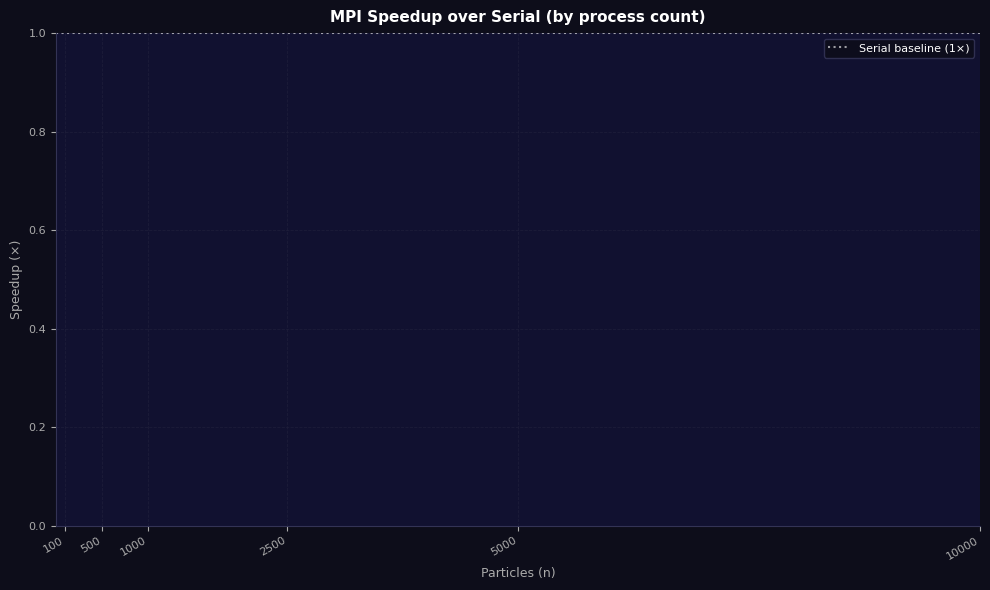

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)

for dset, label, nproc in mpi_datasets:
    mpi_sub    = dset[dset['mode'] == 'MPI'].sort_values('particle_count')
    serial_sub = dset[dset['mode'] == 'Serial'].sort_values('particle_count')
    if mpi_sub.empty or serial_sub.empty: continue

    merged = pd.merge(
        mpi_sub[['particle_count','avg_ms']],
        serial_sub[['particle_count','avg_ms']],
        on='particle_count', suffixes=('_mpi','_serial')
    )
    merged['speedup'] = merged['avg_ms_serial'] / merged['avg_ms_mpi']

    ax.plot(merged['particle_count'], merged['speedup'],
            marker=get_marker(label), color=get_color(label),
            linewidth=2.2, markersize=8, label=f'MPI n={nproc} procs')

ax.axhline(1.0, color='white', linestyle=':', linewidth=1.5,
           alpha=0.6, label='Serial baseline (1×)')

style(ax, 'MPI Speedup over Serial (by process count)',
      'Particles (n)', 'Speedup (×)')
ax.set_xticks(sizes)
ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph5_mpi_speedup.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 12. Graph 6 — MPI Process Count Bar Chart (n=1000)

Saved → results\graph6_mpi_bar.png


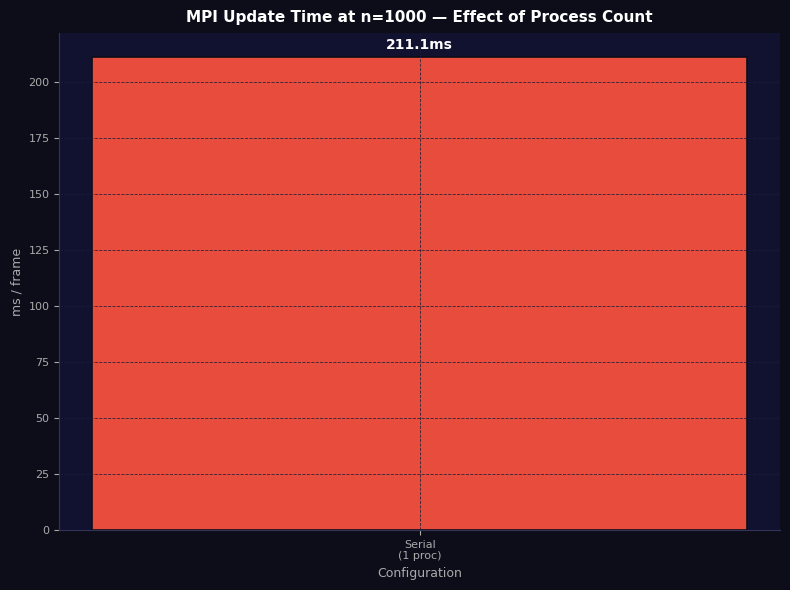

In [29]:
fixed_n = 1000
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG)

labels     = []
times      = []
bar_colors = []

serial_val = gpu_df[(gpu_df['mode'] == 'Serial') &
                    (gpu_df['particle_count'] == fixed_n)]['avg_ms'].values
if len(serial_val) > 0:
    labels.append('Serial\n(1 proc)')
    times.append(serial_val[0])
    bar_colors.append(get_color('Serial'))

for dset, label, nproc in mpi_datasets:
    row = dset[(dset['mode'] == 'MPI') &
               (dset['particle_count'] == fixed_n)]
    if not row.empty:
        labels.append(f'MPI\nn={nproc}')
        times.append(row['avg_ms'].values[0])
        bar_colors.append(get_color(label))

bars = ax.bar(labels, times, color=bar_colors,
              edgecolor='#0d0d1a', linewidth=1.2, width=0.55)

for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(times) * 0.01,
            f'{val:.1f}ms', ha='center', va='bottom',
            color='white', fontsize=10, fontweight='bold')

style(ax, f'MPI Update Time at n={fixed_n} — Effect of Process Count',
      'Configuration', 'ms / frame', legend=False)

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph6_mpi_bar.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 13. Graph 7 — Speedup Heatmap

Saved → results\graph7_heatmap.png


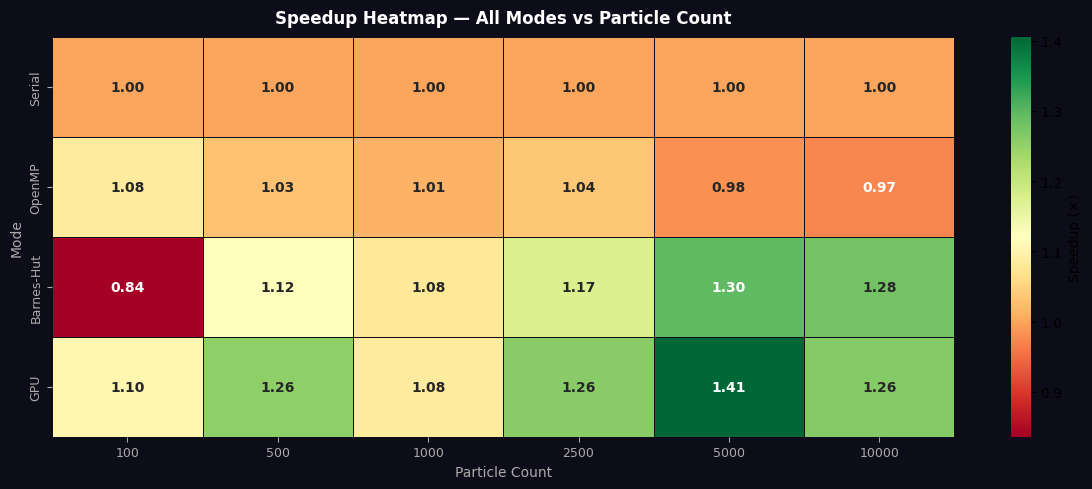

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)

pivot = gpu_df.pivot_table(index='mode', columns='particle_count',
                            values='speedup', aggfunc='mean')
row_order = [r for r in ['Serial','OpenMP','Barnes-Hut','GPU'] if r in pivot.index]
pivot = pivot.reindex(row_order)

sns.heatmap(pivot, ax=ax, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0d0d1a',
            cbar_kws={'label': 'Speedup (×)'},
            annot_kws={'size': 10, 'weight': 'bold'})

ax.set_facecolor(PANEL_BG)
ax.set_title('Speedup Heatmap — All Modes vs Particle Count',
             color='white', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Particle Count', color='#aaaaaa', fontsize=10)
ax.set_ylabel('Mode', color='#aaaaaa', fontsize=10)
ax.tick_params(colors='#aaaaaa', labelsize=9)

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph7_heatmap.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 14. Graph 8 — Barnes-Hut vs Brute Force Speedup

Saved → results\graph8_barneshut_speedup.png


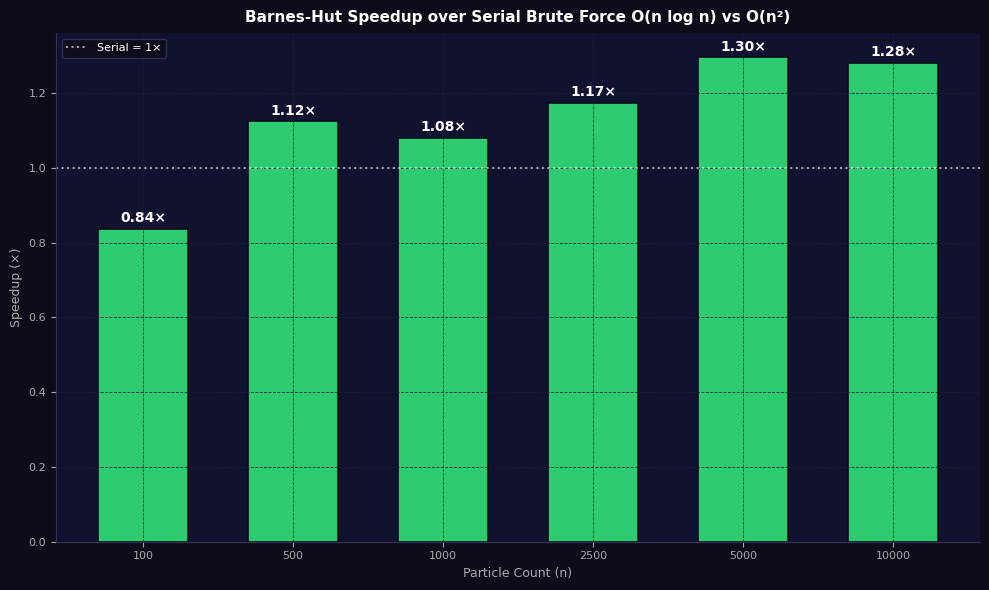

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)

serial_times = gpu_df[gpu_df['mode'] == 'Serial'].set_index('particle_count')['avg_ms']
bh_times     = gpu_df[gpu_df['mode'] == 'Barnes-Hut'].set_index('particle_count')['avg_ms']
common       = serial_times.index.intersection(bh_times.index)
ratio        = serial_times[common] / bh_times[common]

bars = ax.bar([str(n) for n in common], ratio.values,
              color=get_color('Barnes-Hut'), edgecolor='#0d0d1a',
              linewidth=1.2, width=0.6)
ax.axhline(1.0, color='white', linestyle=':', linewidth=1.5, alpha=0.6,
           label='Serial = 1×')

for i, (n, val) in enumerate(zip(common, ratio.values)):
    ax.text(i, val + 0.01, f'{val:.2f}×',
            ha='center', va='bottom', color='white',
            fontsize=10, fontweight='bold')

style(ax, 'Barnes-Hut Speedup over Serial Brute Force O(n log n) vs O(n²)',
      'Particle Count (n)', 'Speedup (×)', legend=True)

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph8_barneshut_speedup.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 15. Graph 9 — Full 9-Panel Summary (All Graphs Combined)

Saved → results\graph9_full_summary.png


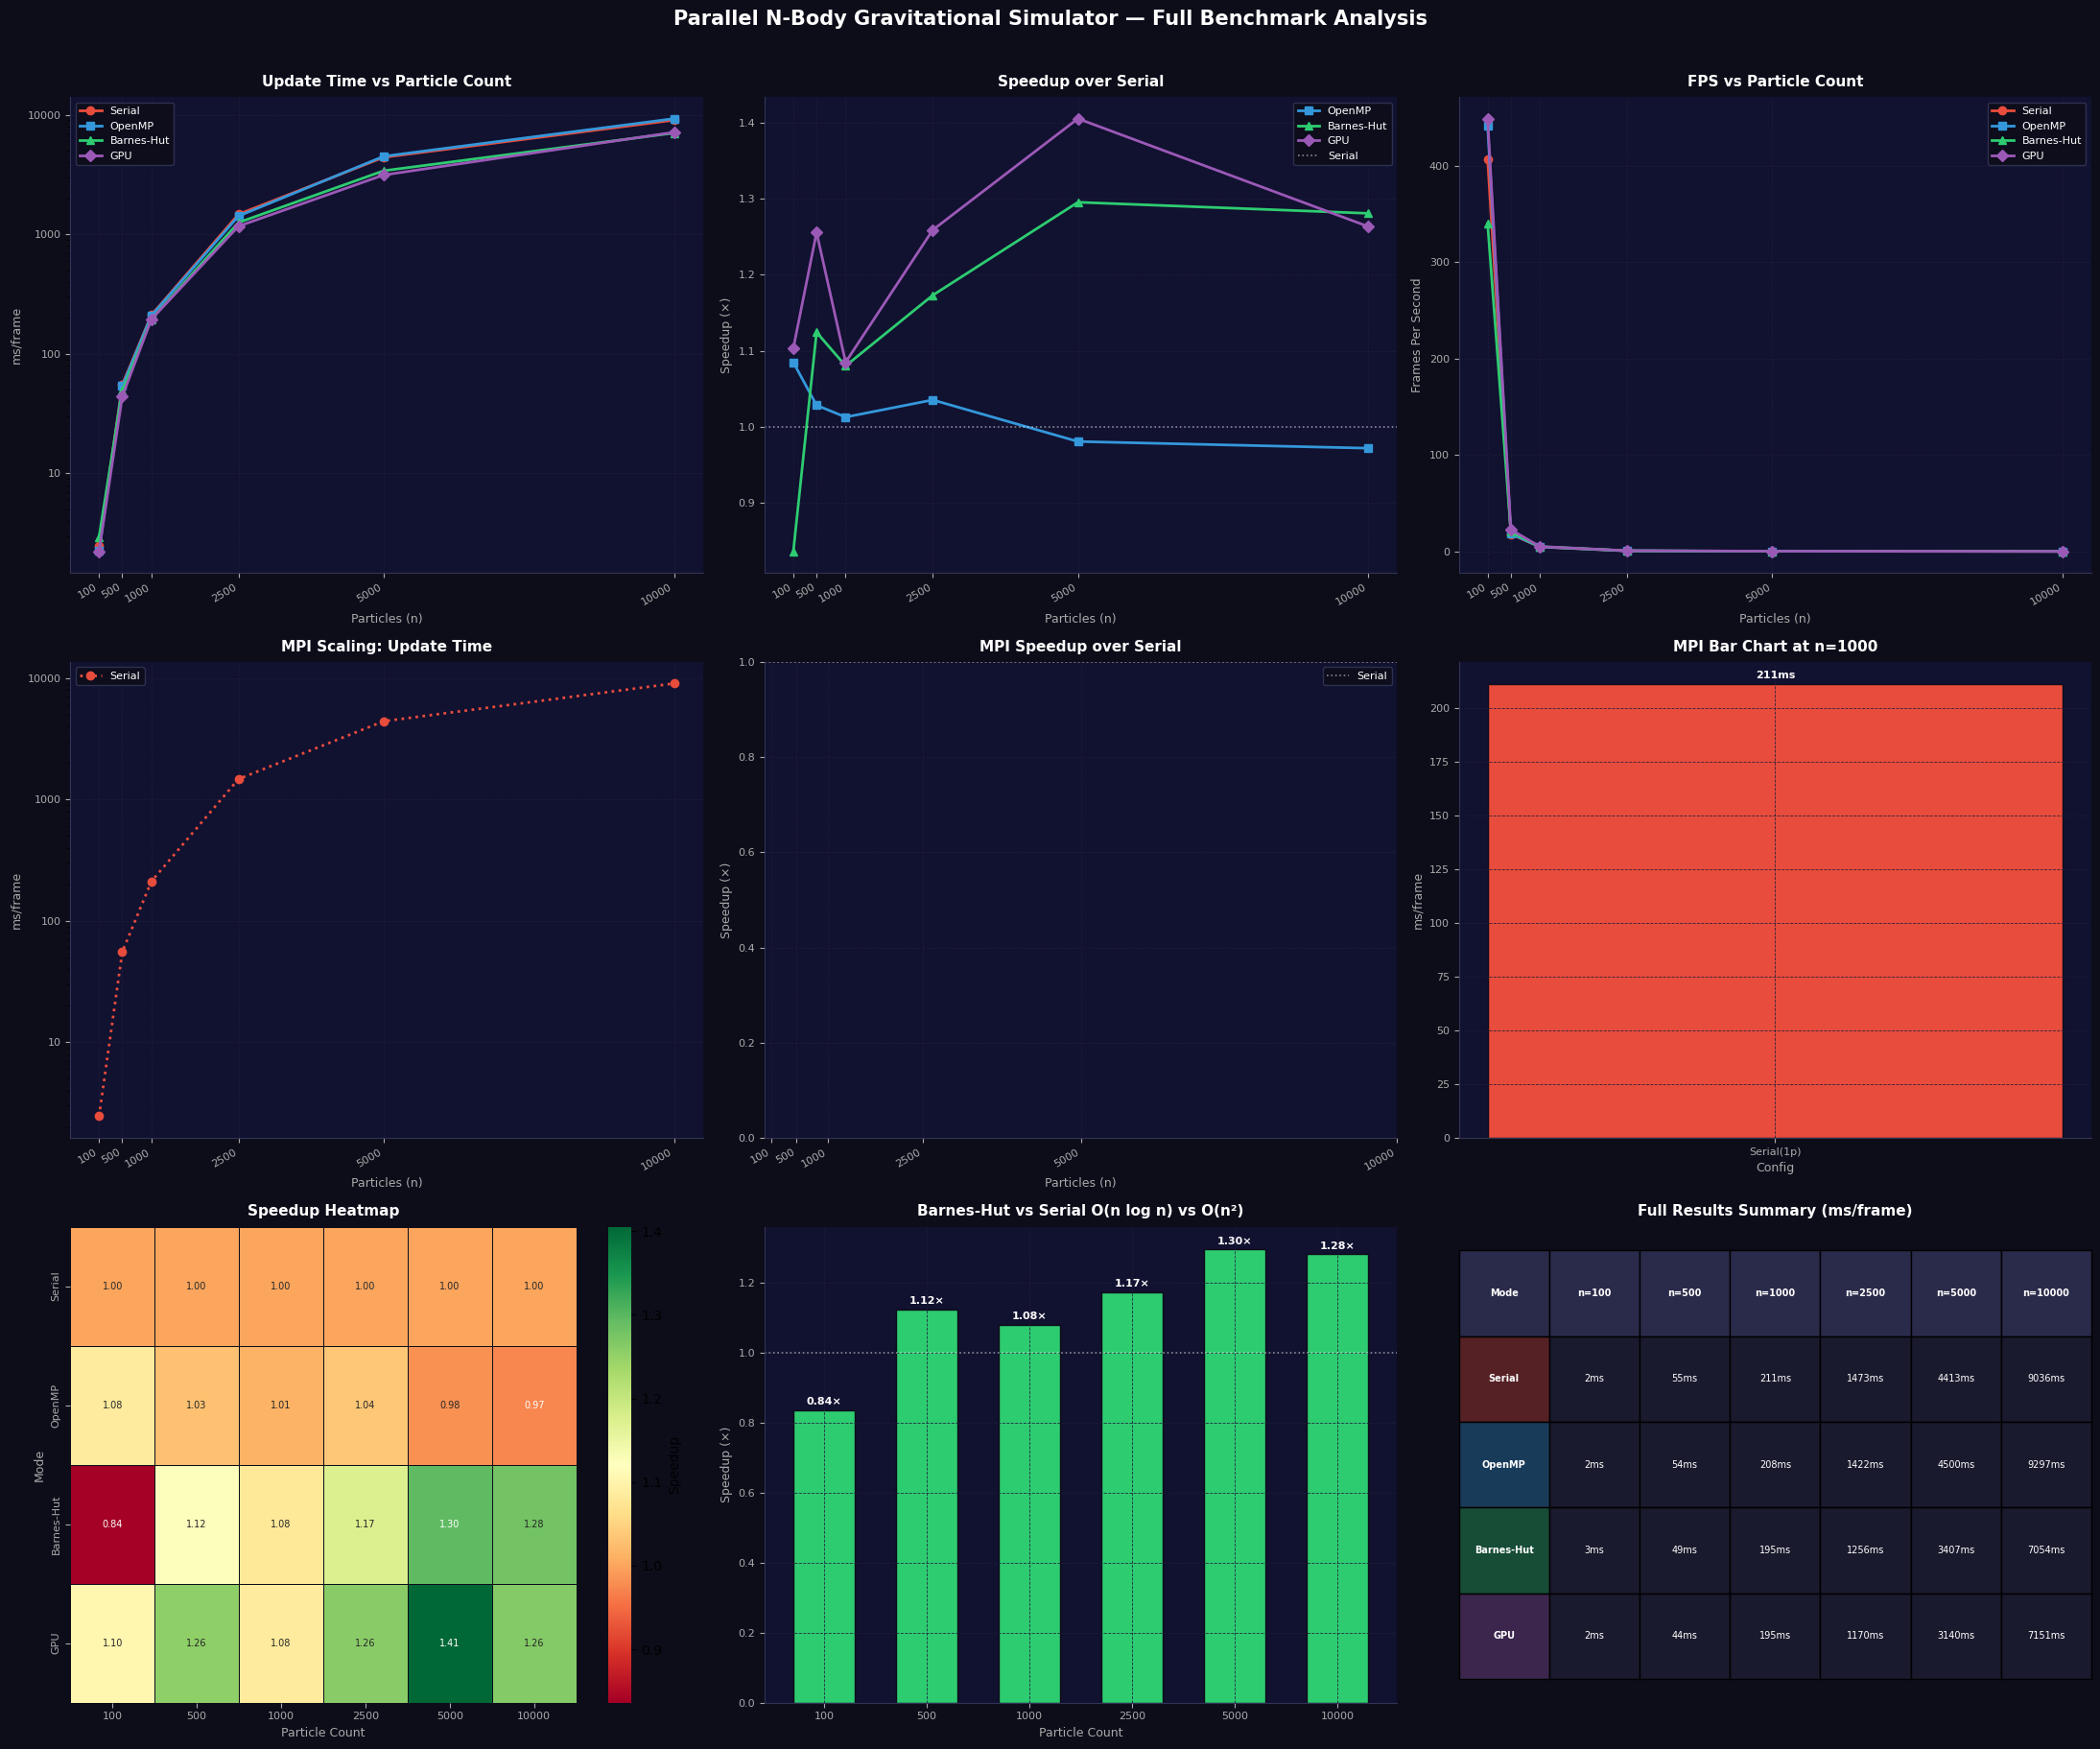

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.patch.set_facecolor(BG)
fig.suptitle('Parallel N-Body Gravitational Simulator — Full Benchmark Analysis',
             fontsize=15, fontweight='bold', color='white', y=1.01)

# Panel 1: Update time log scale
ax = axes[0, 0]
for mode in ['Serial', 'OpenMP', 'Barnes-Hut', 'GPU']:
    sub = gpu_df[gpu_df['mode'] == mode].sort_values('particle_count')
    if sub.empty: continue
    ax.plot(sub['particle_count'], sub['avg_ms'],
            marker=get_marker(mode), color=get_color(mode),
            linewidth=2, markersize=6, label=mode)
style(ax, 'Update Time vs Particle Count', 'Particles (n)', 'ms/frame', log_y=True)
ax.set_xticks(sizes); ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

# Panel 2: Speedup
ax = axes[0, 1]
for mode in ['OpenMP', 'Barnes-Hut', 'GPU']:
    sub = gpu_df[gpu_df['mode'] == mode].sort_values('particle_count')
    if sub.empty: continue
    ax.plot(sub['particle_count'], sub['speedup'],
            marker=get_marker(mode), color=get_color(mode),
            linewidth=2, markersize=6, label=mode)
ax.axhline(1.0, color='white', linestyle=':', linewidth=1.2, alpha=0.5, label='Serial')
style(ax, 'Speedup over Serial', 'Particles (n)', 'Speedup (×)')
ax.set_xticks(sizes); ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

# Panel 3: FPS
ax = axes[0, 2]
for mode in ['Serial', 'OpenMP', 'Barnes-Hut', 'GPU']:
    sub = gpu_df[gpu_df['mode'] == mode].sort_values('particle_count')
    if sub.empty: continue
    ax.plot(sub['particle_count'], sub['fps'],
            marker=get_marker(mode), color=get_color(mode),
            linewidth=2, markersize=6, label=mode)
style(ax, 'FPS vs Particle Count', 'Particles (n)', 'Frames Per Second')
ax.set_xticks(sizes); ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

# Panel 4: MPI scaling time
ax = axes[1, 0]
serial_sub = gpu_df[gpu_df['mode'] == 'Serial'].sort_values('particle_count')
ax.plot(serial_sub['particle_count'], serial_sub['avg_ms'],
        marker='o', color=get_color('Serial'), linewidth=2,
        markersize=6, label='Serial', linestyle=':')
for dset, label, nproc in mpi_datasets:
    sub = dset[dset['mode'] == 'MPI'].sort_values('particle_count')
    if sub.empty: continue
    ax.plot(sub['particle_count'], sub['avg_ms'],
            marker=get_marker(label), color=get_color(label),
            linewidth=2, markersize=6, label=f'MPI n={nproc}')
style(ax, 'MPI Scaling: Update Time', 'Particles (n)', 'ms/frame', log_y=True)
ax.set_xticks(sizes); ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

# Panel 5: MPI speedup
ax = axes[1, 1]
for dset, label, nproc in mpi_datasets:
    mpi_sub    = dset[dset['mode'] == 'MPI'].sort_values('particle_count')
    serial_sub = dset[dset['mode'] == 'Serial'].sort_values('particle_count')
    if mpi_sub.empty or serial_sub.empty: continue
    merged = pd.merge(mpi_sub[['particle_count','avg_ms']],
                      serial_sub[['particle_count','avg_ms']],
                      on='particle_count', suffixes=('_mpi','_serial'))
    merged['speedup'] = merged['avg_ms_serial'] / merged['avg_ms_mpi']
    ax.plot(merged['particle_count'], merged['speedup'],
            marker=get_marker(label), color=get_color(label),
            linewidth=2, markersize=6, label=f'MPI n={nproc}')
ax.axhline(1.0, color='white', linestyle=':', linewidth=1.2, alpha=0.5, label='Serial')
style(ax, 'MPI Speedup over Serial', 'Particles (n)', 'Speedup (×)')
ax.set_xticks(sizes); ax.set_xticklabels([str(s) for s in sizes], rotation=30, ha='right')

# Panel 6: MPI bar at n=1000
ax = axes[1, 2]
fixed_n = 1000
bar_labels, bar_times, bcolors = [], [], []
sv = gpu_df[(gpu_df['mode']=='Serial') & (gpu_df['particle_count']==fixed_n)]['avg_ms'].values
if len(sv): bar_labels.append('Serial(1p)'); bar_times.append(sv[0]); bcolors.append(get_color('Serial'))
for dset, label, nproc in mpi_datasets:
    row = dset[(dset['mode']=='MPI') & (dset['particle_count']==fixed_n)]
    if not row.empty:
        bar_labels.append(f'MPI n={nproc}'); bar_times.append(row['avg_ms'].values[0])
        bcolors.append(get_color(label))
bars = ax.bar(bar_labels, bar_times, color=bcolors, edgecolor='#0d0d1a', linewidth=1, width=0.55)
for bar, val in zip(bars, bar_times):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(bar_times)*0.01,
            f'{val:.0f}ms', ha='center', va='bottom', color='white', fontsize=8, fontweight='bold')
style(ax, f'MPI Bar Chart at n={fixed_n}', 'Config', 'ms/frame', legend=False)

# Panel 7: Heatmap
ax = axes[2, 0]
pivot = gpu_df.pivot_table(index='mode', columns='particle_count', values='speedup', aggfunc='mean')
row_order = [r for r in ['Serial','OpenMP','Barnes-Hut','GPU'] if r in pivot.index]
pivot = pivot.reindex(row_order)
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.4, linecolor='#0d0d1a',
            cbar_kws={'label': 'Speedup'}, annot_kws={'size': 7})
ax.set_title('Speedup Heatmap', color='white', fontsize=11, fontweight='bold', pad=8)
ax.set_xlabel('Particle Count', color='#aaaaaa', fontsize=9)
ax.set_ylabel('Mode', color='#aaaaaa', fontsize=9)
ax.tick_params(colors='#aaaaaa', labelsize=8)
ax.set_facecolor(PANEL_BG)

# Panel 8: Barnes-Hut bar
ax = axes[2, 1]
serial_t = gpu_df[gpu_df['mode']=='Serial'].set_index('particle_count')['avg_ms']
bh_t     = gpu_df[gpu_df['mode']=='Barnes-Hut'].set_index('particle_count')['avg_ms']
common   = serial_t.index.intersection(bh_t.index)
ratio    = serial_t[common] / bh_t[common]
bars2 = ax.bar([str(n) for n in common], ratio.values,
               color=get_color('Barnes-Hut'), edgecolor='#0d0d1a', linewidth=1, width=0.6)
ax.axhline(1.0, color='white', linestyle=':', linewidth=1.2, alpha=0.5)
for i, (n, val) in enumerate(zip(common, ratio.values)):
    ax.text(i, val+0.01, f'{val:.2f}×', ha='center', va='bottom',
            color='white', fontsize=8, fontweight='bold')
style(ax, 'Barnes-Hut vs Serial O(n log n) vs O(n²)', 'Particle Count', 'Speedup (×)', legend=False)

# Panel 9: Summary table
ax = axes[2, 2]
ax.set_facecolor(PANEL_BG)
ax.axis('off')
table_modes = ['Serial','OpenMP','Barnes-Hut','GPU']
col_labels  = ['Mode'] + [f'n={n}' for n in sizes]
rows = []
for mode in table_modes:
    row = [mode]
    for n in sizes:
        val = gpu_df[(gpu_df['mode']==mode) & (gpu_df['particle_count']==n)]['avg_ms']
        row.append(f'{val.values[0]:.0f}ms' if len(val)>0 else '—')
    rows.append(row)
if not mpi4_df.empty:
    row = ['MPI(n=4)']
    for n in sizes:
        val = mpi4_df[(mpi4_df['mode']=='MPI') & (mpi4_df['particle_count']==n)]['avg_ms']
        row.append(f'{val.values[0]:.0f}ms' if len(val)>0 else '—')
    rows.append(row)
tbl = ax.table(cellText=rows, colLabels=col_labels, cellLoc='center',
               loc='center', bbox=[0, 0.05, 1, 0.9])
tbl.auto_set_font_size(False); tbl.set_fontsize(7)
mode_colors = {'Serial': get_color('Serial'), 'OpenMP': get_color('OpenMP'),
               'Barnes-Hut': get_color('Barnes-Hut'), 'GPU': get_color('GPU'),
               'MPI(n=4)': get_color('MPI-4')}
for j in range(len(col_labels)):
    tbl[0,j].set_facecolor('#2a2a4a'); tbl[0,j].set_text_props(color='white', fontweight='bold')
for i, row in enumerate(rows):
    for j in range(len(col_labels)):
        tbl[i+1,j].set_facecolor('#1a1a2e'); tbl[i+1,j].set_text_props(color='white')
    tbl[i+1,0].set_facecolor(mode_colors.get(row[0],'#2a2a4a')+'55')
    tbl[i+1,0].set_text_props(color='white', fontweight='bold')
ax.set_title('Full Results Summary (ms/frame)', color='white', fontsize=11, fontweight='bold', pad=8)

plt.tight_layout()
out = os.path.join(RESULTS_DIR, "graph9_full_summary.png")
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {out}")
plt.show()


## 16. All Saved Files

In [33]:
print("Files saved to results/ folder:")
for f in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, f)
    size  = os.path.getsize(fpath) / 1024
    print(f"  {f:<45} {size:6.1f} KB")


Files saved to results/ folder:
  benchmark_combined.csv                           3.9 KB
  graph1_update_time.png                          84.7 KB
  graph2_speedup.png                              92.9 KB
  graph3_fps.png                                  62.0 KB
  graph4_mpi_scaling_time.png                     61.3 KB
  graph5_mpi_speedup.png                          48.2 KB
  graph6_mpi_bar.png                              38.9 KB
  graph7_heatmap.png                              54.1 KB
  graph8_barneshut_speedup.png                    63.9 KB
  graph9_full_summary.png                        439.8 KB
